<h1 style="color:red;">Numerical Simulation Laboratory - Exercise 4.1</h1>

The aim of this exercise is to study the velocity distribution of a system of particles using a Molecular Dynamics simulation. In particular, we will calculate the **Maxwell-Boltzmann distribution** in reduced units and compare the distribution obtained from the simulation with the theoretical prediction.

The sampled data will be analyzed using the **data blocking method**, allowing us to estimate the statistical uncertainties associated with the simulated distribution.

### Molecular Dynamics Simulation

The Molecular Dynamics simulation considers a system of $N$ particles of mass $m$ confined in a cubic box of side length $L$. **Periodic boundary conditions** are imposed in order to reduce boundary effects and reproduce, as closely as possible, a bulk system where each particle interacts with the surrounding particles rather than with the walls of the simulation box.

The particles interact through the **Lennard-Jones potential**

$$
V(r)=4\epsilon\left[\left(\frac{\sigma}{r}\right)^{12}
-\left(\frac{\sigma}{r}\right)^6\right],
$$

where $\epsilon$ sets the energy scale of the interaction, $\sigma$ is the characteristic distance at which the potential changes sign, and $r$ is the interparticle distance. When calculating the force acting on a particle, the **minimum image convention** is used, so that only the closest periodic image of each of the other $N-1$ particles is considered. Moreover, the interaction is truncated at a fixed cutoff radius $r_c$ in order to reduce the computational cost.

The simulation is performed using **reduced units**, which are defined starting from the characteristic quantities of the Lennard-Jones potential, namely $\epsilon$, $\sigma$ and the particle mass $m$. The corresponding dimensionless quantities can therefore be written as

$$
r^*=\frac{r}{\sigma},
\qquad
V^*=\frac{V}{\epsilon},
\qquad
P^*=\frac{P\sigma^3}{\epsilon},
\qquad
\rho^*=\rho\sigma^3,
\qquad
T^*=\frac{k_B T}{\epsilon}.
$$

In these units, the Lennard-Jones potential takes the simplified form

$$
V^*(r^*)=
4\left[
\frac{1}{(r^*)^{12}}
-\frac{1}{(r^*)^6}
\right].
$$

The use of reduced units simplifies both the equations and their numerical implementation. Furthermore, since the relevant physical quantities are generally of order unity, this choice makes numerical results easier to interpret and can help identify possible errors in the implementation of the simulation.

### Verlet Algorithm

The time evolution of the system is obtained by integrating Newton's equations of motion using the **Verlet algorithm**. The algorithm is derived from a double third-order Taylor expansion of the particle position. By combining the forward and backward expansions, the position at the next time step can be written as

$$
\vec{r}(t+\Delta t)
\simeq
2\vec{r}(t)-\vec{r}(t-\Delta t)
+\vec{a}(t)\Delta t^2.
$$

Therefore, the position at the current step is determined from the positions at the two previous steps and the acceleration at the current time. The Verlet algorithm has an error of order $\mathcal{O}(\Delta t^2)$ and is **time reversible**, making it particularly suitable for Molecular Dynamics simulations. It also provides good energy conservation over long trajectories.

The velocities are not directly computed by the standard Verlet algorithm, but can be reconstructed from the particle positions using a finite-difference approximation of the trajectory.

$$
\vec{v}(t)
\simeq
\frac{\vec{r}(t+\Delta t)-\vec{r}(t-\Delta t)}
{2\Delta t}.
$$

### Probability of velocity

In Statistical Mechanics the Maxwell–Boltzmann distribution (<a href="https://en.wikipedia.org/wiki/Maxwell%E2%80%93Boltzmann_distribution" target="_blank">Link Wikipedia</a>) is a probability distribution used for describing particle speeds in idealized gases. However, rarefied gases at ordinary temperatures behave very nearly like an ideal gas and the Maxwell–Boltzmann speed distribution is an excellent approximation for such gases. For a 3D system its formula is:
$$p(v,T) = \left( \frac{m}{2\pi k_B T} \right)^{3/2} 4\pi v^2 e^{-\frac{m v^2}{2 k_B T}}$$

By using LJ reduced units (Lenght: $\sigma$; Energy: $\epsilon$; Mass: the mass, $m$, of the particles; Temperature: $\epsilon/k_B$; velocity: $\sqrt{\epsilon/m}$) its form becomes:
$$p(v^*,T^*) = \frac{1}{(2\pi T^*)^{3/2}} 4\pi (v^*)^2 e^{-\frac{(v^*)^2}{2 T^*}}$$

The NSL_SIMULATOR code already computes the total (internal) energy per particle, $E/N$, the potential energy per particle, $U/N$, the kinetic energy per particle, $K/N$, the temperature, $T$, and the pressure, $P$. In this exercise, the calculation of POFV has also been added

### Simulation Setup and Data Analysis

The Maxwell-Boltzmann velocity distribution is obtained by using the **POFV** property and the corresponding number of bins ($30$ in this exercise), specified in the `properties.dat` file. The main parameters of the simulation are initialized in the `input.dat` file:

**Temperature**=2  
**Number of particles**=108  
**Density**=0.05  
**Cutoff radius**=5.0  
**Time step**=0.001  
**Number of blocks**=20  
**Number of steps per block**=2000  

The width of each velocity bin is defined as

$$
\Delta v = \frac{v_{\max}}{N_{\mathrm{bins}}},
$$

where the maximum velocity is chosen as

$$
v_{\max}=k\sqrt{T^*},
$$

with $k=4$.

During each measurement, the modulus of the velocity of each particle is calculated and the corresponding bin is incremented. The resulting histogram is then normalized to obtain the velocity distribution.

Finally, the collected measurements are analyzed using the **data blocking method**. For each block, the average value of the distribution is calculated, together with the progressive averages and the corresponding statistical uncertainties. This procedure allows us to obtain the velocity distribution and its statistical error from the Molecular Dynamics simulation.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [2]:
data = np.loadtxt("nsl_simulator/NSL_SIMULATOR/OUTPUT/pofv.dat", skiprows=1)

In [3]:
block = data[:, 0]

last_block = np.max(block)

data_last = data[block == last_block]

In [4]:
velocity = data_last[:, 1]
ave_pofv = data_last[:, 2]
ave_prog = data_last[:, 3]
error = data_last[:, 4]

T = 2.18323

v_theory = np.linspace(0, np.max(velocity), 500)
pofv_theory = (4 / np.sqrt(np.pi)
    * (1 / (2 * T))**(3/2)
    * v_theory**2
    * np.exp(-v_theory**2 / (2 * T)))

dv = velocity[1] - velocity[0]

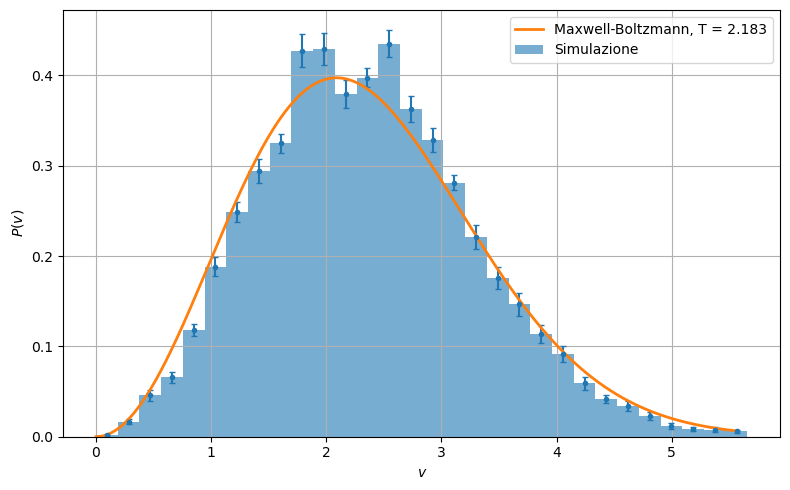

In [5]:
plt.figure(figsize = (8, 5))

plt.bar(velocity, ave_prog, width = dv, alpha = 0.6, label = "Simulazione")

plt.errorbar(velocity, ave_prog, yerr=error, fmt = "o", markersize = 3, capsize = 2)

plt.plot(v_theory, pofv_theory, linewidth = 2, label = f"Maxwell-Boltzmann, T = {T:.3f}")

plt.xlabel(r"$v$")
plt.ylabel(r"$P(v)$")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

**Figure 1.** The histogram shows the progressive averages of the velocity distribution obtained from the Molecular Dynamics simulation, together with the corresponding statistical uncertainties. The theoretical Maxwell-Boltzmann distribution is evaluated using the temperature obtained from the average of the last block, $T^*=2.18323$, since temperature is not a conserved quantity in the Molecular Dynamics simulation. The simulated distribution shows good agreement with the theoretical prediction, particularly in the tails of the distribution. A small discrepancy is instead observed around the peak, where the theoretical prediction lies outside the error bars of the simulated values. Overall, the results reproduce the expected Maxwell-Boltzmann behaviour reasonably well.